#**Case Study: Sales Analysis**

This case study uses Pandas and Matplotlib to analyze and visualize some sales data.
This case study explore four business questions related to the data:

*   What was the best month for sales? How much was earned in that month?
*   What city sold the most products?
*   What time should we display advertisements to maximize the likelihood of customers buying products?
*   What product sold the most?




In [1]:
# mount google colab drive, just need to do this once
from google.colab import drive
drive.mount('/content/gdrive')

data_dir = '/content/gdrive/My Drive/Colab Notebooks/Case_Study/Sales_Analysis/Datasets'

Mounted at /content/gdrive


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MaxNLocator, FuncFormatter  # Import MaxNLocator and FuncFormatter

#Merge CSV Data from Each Month

In [3]:
# create a dataframe
all_data = pd.DataFrame()

In [4]:
# read from all files
files = [file for file in os.listdir(data_dir) if not file.startswith('.')] # Ignore hidden files
for file in files:
    current_data = pd.read_csv(f"{data_dir}/{file}")
    all_data = pd.concat([all_data, current_data], ignore_index=True)

In [5]:
print(all_data.shape)
all_data.head(60)

(186850, 6)


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,222910,Apple Airpods Headphones,1,150,07/26/19 16:51,"389 South St, Atlanta, GA 30301"
1,222911,Flatscreen TV,1,300,07/05/19 08:55,"590 4th St, Seattle, WA 98101"
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301"
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301"
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101"
5,222915,Bose SoundSport Headphones,1,99.99,07/03/19 18:30,"899 Elm St, San Francisco, CA 94016"
6,222916,Google Phone,1,600,07/21/19 22:39,"745 Chestnut St, New York City, NY 10001"
7,222917,LG Dryer,1,600.0,07/17/19 13:44,"490 Adams St, New York City, NY 10001"
8,222918,USB-C Charging Cable,1,11.95,07/14/19 21:16,"207 1st St, Los Angeles, CA 90001"
9,222919,Lightning Charging Cable,1,14.95,07/14/19 13:24,"29 Jefferson St, Dallas, TX 75001"


In [6]:
# write to a single file
all_data.to_csv(f"{data_dir}/all_sales_data.csv", index=False)

#Clean Up Data

In [7]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


## Remove Repeated Column Header

In [8]:
all_data.head(967)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,222910,Apple Airpods Headphones,1,150,07/26/19 16:51,"389 South St, Atlanta, GA 30301"
1,222911,Flatscreen TV,1,300,07/05/19 08:55,"590 4th St, Seattle, WA 98101"
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301"
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301"
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101"
...,...,...,...,...,...,...
962,223834,27in FHD Monitor,1,149.99,07/09/19 08:33,"818 Forest St, Los Angeles, CA 90001"
963,223835,AA Batteries (4-pack),2,3.84,07/04/19 11:23,"554 Wilson St, Austin, TX 73301"
964,223836,Lightning Charging Cable,1,14.95,07/12/19 05:48,"350 Pine St, Atlanta, GA 30301"
965,223837,USB-C Charging Cable,1,11.95,07/09/19 21:52,"681 Main St, Austin, TX 73301"


In [10]:
# get rid of repeated column hearder
all_data = all_data[all_data['Order Date'].str[0:2]!='Or']

In [11]:
all_data.head(944)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,222910,Apple Airpods Headphones,1,150,07/26/19 16:51,"389 South St, Atlanta, GA 30301"
1,222911,Flatscreen TV,1,300,07/05/19 08:55,"590 4th St, Seattle, WA 98101"
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301"
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301"
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101"
...,...,...,...,...,...,...
940,223812,Bose SoundSport Headphones,1,99.99,07/15/19 20:58,"36 Willow St, San Francisco, CA 94016"
941,223813,iPhone,1,700,07/05/19 20:15,"690 8th St, Los Angeles, CA 90001"
942,223814,USB-C Charging Cable,1,11.95,07/25/19 17:07,"83 Adams St, Dallas, TX 75001"
943,223815,Lightning Charging Cable,1,14.95,07/06/19 15:08,"406 Church St, Los Angeles, CA 90001"


## Remove Rows Containing NaN

In [12]:
# check rows with any NaN
nan_df = all_data[all_data.isna().any(axis=1)]
nan_df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
199,NaN,NaN,NaN,NaN,NaN,NaN
315,NaN,NaN,NaN,NaN,NaN,NaN
599,NaN,NaN,NaN,NaN,NaN,NaN
675,NaN,NaN,NaN,NaN,NaN,NaN
1027,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
184390,NaN,NaN,NaN,NaN,NaN,NaN
184779,NaN,NaN,NaN,NaN,NaN,NaN
185239,NaN,NaN,NaN,NaN,NaN,NaN
185614,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# drop rows
all_data = all_data.dropna(how='all')
all_data.head(60)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,222910,Apple Airpods Headphones,1,150,07/26/19 16:51,"389 South St, Atlanta, GA 30301"
1,222911,Flatscreen TV,1,300,07/05/19 08:55,"590 4th St, Seattle, WA 98101"
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301"
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301"
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101"
5,222915,Bose SoundSport Headphones,1,99.99,07/03/19 18:30,"899 Elm St, San Francisco, CA 94016"
6,222916,Google Phone,1,600,07/21/19 22:39,"745 Chestnut St, New York City, NY 10001"
7,222917,LG Dryer,1,600.0,07/17/19 13:44,"490 Adams St, New York City, NY 10001"
8,222918,USB-C Charging Cable,1,11.95,07/14/19 21:16,"207 1st St, Los Angeles, CA 90001"
9,222919,Lightning Charging Cable,1,14.95,07/14/19 13:24,"29 Jefferson St, Dallas, TX 75001"


## Convert Some Columns to Numerics

In [14]:
# convert some columns to numerics
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,222910,Apple Airpods Headphones,1,150.00,07/26/19 16:51,"389 South St, Atlanta, GA 30301"
1,222911,Flatscreen TV,1,300.00,07/05/19 08:55,"590 4th St, Seattle, WA 98101"
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301"
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301"
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101"
...,...,...,...,...,...,...
186845,278792,AA Batteries (4-pack),1,3.84,10/12/19 04:32,"920 Adams St, San Francisco, CA 94016"
186846,278793,Wired Headphones,1,11.99,10/28/19 22:00,"161 Chestnut St, Los Angeles, CA 90001"
186847,278794,AA Batteries (4-pack),1,3.84,10/09/19 20:58,"346 Spruce St, San Francisco, CA 94016"
186848,278795,iPhone,1,700.00,10/31/19 17:21,"291 Hill St, Seattle, WA 98101"


## Add Additional Columns

In [15]:
# add an additional month column
all_data['Month'] = pd.to_datetime(all_data['Order Date']).dt.month
all_data.head()

# # alternative to add month column
#all_data['Month'] = all_data['Order Date'].str[0:2]
#all_data['Month'] = pd.to_numeric(all_data['Month'])

<ipython-input-15-4fb042aebfc6>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Month'] = pd.to_datetime(all_data['Order Date']).dt.month


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,222910,Apple Airpods Headphones,1,150.00,07/26/19 16:51,"389 South St, Atlanta, GA 30301",7
1,222911,Flatscreen TV,1,300.00,07/05/19 08:55,"590 4th St, Seattle, WA 98101",7
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301",7
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301",7
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101",7


In [16]:
# add a city (State) column
def get_city(address):
    if isinstance(address, str):
        return address.split(",")[1].strip(" ")
    return None

def get_state(address):
    if isinstance(address, str):
        return address.split(",")[2].split(" ")[1]
    return None

all_data['City'] = all_data['Purchase Address'].apply(lambda x: f"{get_city(x)}  ({get_state(x)})")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City
0,222910,Apple Airpods Headphones,1,150.00,07/26/19 16:51,"389 South St, Atlanta, GA 30301",7,Atlanta (GA)
1,222911,Flatscreen TV,1,300.00,07/05/19 08:55,"590 4th St, Seattle, WA 98101",7,Seattle (WA)
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301",7,Atlanta (GA)
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301",7,Atlanta (GA)
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101",7,Seattle (WA)


#Explore Data


##Question 1

What was the best month for sales? How much was earned that month?

In [17]:
# add a sales column
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales
0,222910,Apple Airpods Headphones,1,150.00,07/26/19 16:51,"389 South St, Atlanta, GA 30301",7,Atlanta (GA),150.00
1,222911,Flatscreen TV,1,300.00,07/05/19 08:55,"590 4th St, Seattle, WA 98101",7,Seattle (WA),300.00
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301",7,Atlanta (GA),3.84
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301",7,Atlanta (GA),3.84
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101",7,Seattle (WA),14.95


In [24]:
# sum of sales by months
monthly_sales = all_data.groupby('Month').sum()
monthly_sales['Sales']

# Converted data to series
monthly_sales_series = pd.Series(monthly_sales['Sales'],
                          name='Sales')

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64


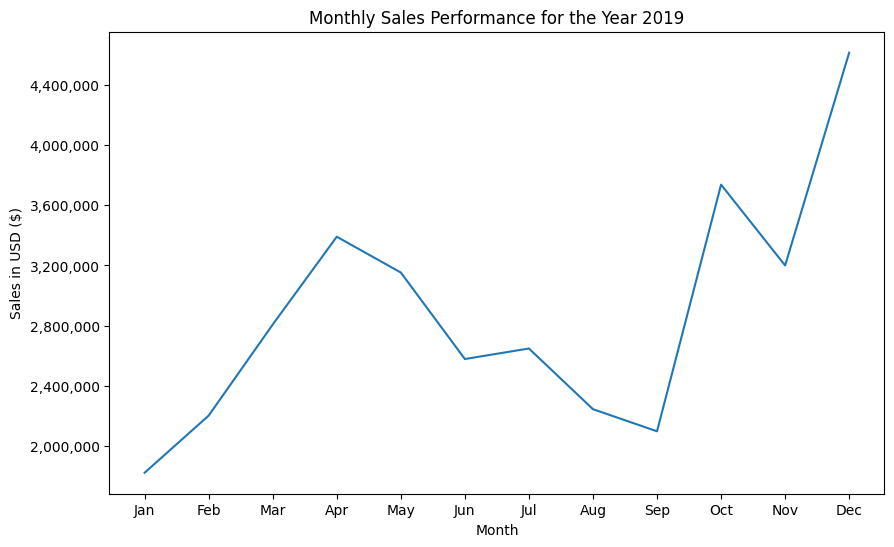

Best selling month: 12
Sales amount： 4613443.34


In [36]:
# plot a sales line graph
months = range(1,13)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(10, 6))

plt.plot(months, monthly_sales['Sales'])
plt.xticks(months, month_names)
plt.ylabel('Sales in USD ($)')
plt.xlabel('Month')

plt.title('Monthly Sales Performance for the Year 2019')

# Adjust the y-axis to prevent scientific notation
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))  # Ensure integer ticks
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Format as integer

# plt.legend()
plt.show()

# max sales month
print(f"Best selling month: {monthly_sales.Sales.idxmax()}")
print(f"Sales amount： {monthly_sales.Sales.max()}")

## Question 2

What city sold the most product that year?


In [37]:
city_sales = all_data.groupby(['City']).sum()
print(city_sales)

                                                              Order ID  \
City                                                                     
Atlanta  (GA)        2229102229122229132229562229702229802230002230...   
Austin  (TX)         2229712229812229842230052230122230272230402230...   
Boston  (MA)         2229292229312229362229632229642229832229982230...   
Dallas  (TX)         2229192229222229382229492229502229542229582229...   
Los Angeles  (CA)    2229182229232229262229272229322229332229392229...   
New York City  (NY)  2229162229172229462229472229872229902229942229...   
Portland  (ME)       2231342232512233112234052234062234322234462235...   
Portland  (OR)       2229422229572229822230072230342230352230482230...   
San Francisco  (CA)  2229152229202229212229242229252229282229302229...   
Seattle  (WA)        2229112229142229342229432229622229662229722229...   

                                                               Product  \
City                                 

In [38]:
# sort sales by descending order
city_sales = city_sales.sort_values(by=['Sales'], ascending=False)
print(city_sales)

                                                              Order ID  \
City                                                                     
San Francisco  (CA)  2229152229202229212229242229252229282229302229...   
Los Angeles  (CA)    2229182229232229262229272229322229332229392229...   
New York City  (NY)  2229162229172229462229472229872229902229942229...   
Boston  (MA)         2229292229312229362229632229642229832229982230...   
Atlanta  (GA)        2229102229122229132229562229702229802230002230...   
Dallas  (TX)         2229192229222229382229492229502229542229582229...   
Seattle  (WA)        2229112229142229342229432229622229662229722229...   
Portland  (OR)       2229422229572229822230072230342230352230482230...   
Austin  (TX)         2229712229812229842230052230122230272230402230...   
Portland  (ME)       2231342232512233112234052234062234322234462235...   

                                                               Product  \
City                                 

In [39]:
city_sales.reset_index(inplace=True)
print(city_sales)

                  City                                           Order ID  \
0  San Francisco  (CA)  2229152229202229212229242229252229282229302229...   
1    Los Angeles  (CA)  2229182229232229262229272229322229332229392229...   
2  New York City  (NY)  2229162229172229462229472229872229902229942229...   
3         Boston  (MA)  2229292229312229362229632229642229832229982230...   
4        Atlanta  (GA)  2229102229122229132229562229702229802230002230...   
5         Dallas  (TX)  2229192229222229382229492229502229542229582229...   
6        Seattle  (WA)  2229112229142229342229432229622229662229722229...   
7       Portland  (OR)  2229422229572229822230072230342230352230482230...   
8         Austin  (TX)  2229712229812229842230052230122230272230402230...   
9       Portland  (ME)  2231342232512233112234052234062234322234462235...   

                                             Product  Quantity Ordered  \
0  Bose SoundSport HeadphonesAA Batteries (4-pack...             50239   
1  U

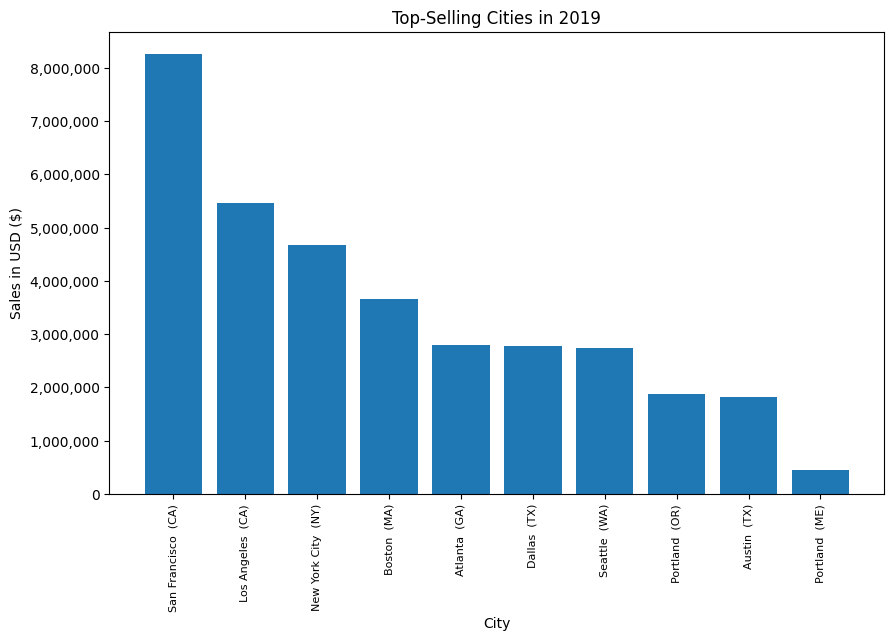

Most selling city: San Francisco  (CA)


In [44]:
# plot a sales bar graph
plt.figure(figsize=(10, 6))

plt.bar(city_sales['City'], city_sales['Sales'])
plt.ylabel('Sales in USD ($)')
plt.xlabel('City')
plt.xticks(city_sales['City'], rotation='vertical', size=8)

plt.title(f'Top-Selling Cities in 2019')



# Adjust the y-axis to prevent scientific notation
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))  # Ensure integer ticks
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # Format as integer

plt.show()

# most selling city
most_selling_city = city_sales['City'][city_sales['Sales'] == city_sales['Sales'].max()].to_string().strip("0 ")
print(f"Most selling city: {most_selling_city}")

## Question 3

What time should we display advertisements to maximize likelihood of customer's buying of products?


In [45]:
# Add hour column
all_data['Hour'] = pd.to_datetime(all_data['Order Date']).dt.hour
all_data.head()

<ipython-input-45-c04f54e35e42>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Hour'] = pd.to_datetime(all_data['Order Date']).dt.hour


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales,Hour
0,222910,Apple Airpods Headphones,1,150.00,07/26/19 16:51,"389 South St, Atlanta, GA 30301",7,Atlanta (GA),150.00,16
1,222911,Flatscreen TV,1,300.00,07/05/19 08:55,"590 4th St, Seattle, WA 98101",7,Seattle (WA),300.00,8
2,222912,AA Batteries (4-pack),1,3.84,07/29/19 12:41,"861 Hill St, Atlanta, GA 30301",7,Atlanta (GA),3.84,12
3,222913,AA Batteries (4-pack),1,3.84,07/28/19 10:15,"190 Ridge St, Atlanta, GA 30301",7,Atlanta (GA),3.84,10
4,222914,AAA Batteries (4-pack),5,2.99,07/31/19 02:13,"824 Forest St, Seattle, WA 98101",7,Seattle (WA),14.95,2


In [46]:
sales_by_hour = all_data.groupby(['Hour']).count()   # number of transactions
sales_by_hour

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales
Hour,,,,,,,,,
0,3910,3910,3910,3910,3910,3910,3910,3910,3910
1,2350,2350,2350,2350,2350,2350,2350,2350,2350
2,1243,1243,1243,1243,1243,1243,1243,1243,1243
3,831,831,831,831,831,831,831,831,831
4,854,854,854,854,854,854,854,854,854
5,1321,1321,1321,1321,1321,1321,1321,1321,1321
6,2482,2482,2482,2482,2482,2482,2482,2482,2482
7,4011,4011,4011,4011,4011,4011,4011,4011,4011
8,6256,6256,6256,6256,6256,6256,6256,6256,6256


In [47]:
sales_by_hour.reset_index(inplace=True)
sales_by_hour

,Hour,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales
0,0,3910,3910,3910,3910,3910,3910,3910,3910,3910
1,1,2350,2350,2350,2350,2350,2350,2350,2350,2350
2,2,1243,1243,1243,1243,1243,1243,1243,1243,1243
3,3,831,831,831,831,831,831,831,831,831
4,4,854,854,854,854,854,854,854,854,854
5,5,1321,1321,1321,1321,1321,1321,1321,1321,1321
6,6,2482,2482,2482,2482,2482,2482,2482,2482,2482
7,7,4011,4011,4011,4011,4011,4011,4011,4011,4011
8,8,6256,6256,6256,6256,6256,6256,6256,6256,6256
9,9,8748,8748,8748,8748,8748,8748,8748,8748,8748


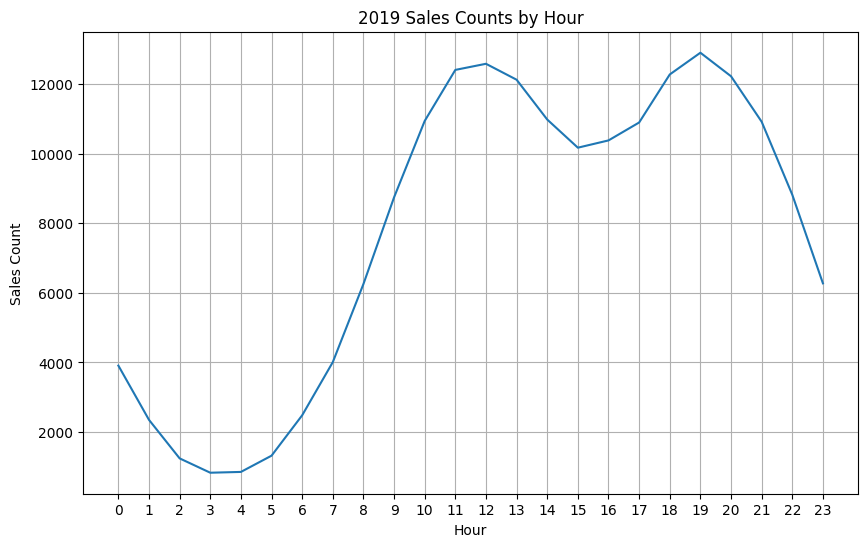

Best time for ads: 19h


In [51]:
plt.figure(figsize=(10, 6))
plt.plot(sales_by_hour['Hour'], sales_by_hour['Order ID'])
plt.xticks(sales_by_hour['Hour'])
plt.ylabel('Sales Count')
plt.xlabel('Hour')
plt.grid()

plt.title('2019 Sales Counts by Hour')
plt.show()

# best time for ads:
print(f"Best time for ads: {sales_by_hour.Product.idxmax()}h")

##Question 4

What product sold the most (in terms of quantity sold and total value)?

In [52]:
sales_by_product = all_data.groupby('Product').sum()
sales_by_product

,Order ID,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales,Hour
Product,,,,,,,,,
20in Monitor,2229462229672231042231772231852232222232622232...,4129,451068.99,07/14/19 22:1907/14/19 11:5807/08/19 07:2907/2...,"49 Park St, New York City, NY 10001161 13th St...",29336,New York City (NY)San Francisco (CA)Los Ange...,454148.71,58764
27in 4K Gaming Monitor,2229562230412230792231132231252231382231842232...,6244,2429637.70,07/11/19 20:1807/11/19 08:1607/18/19 10:2207/0...,"525 6th St, Atlanta, GA 30301330 River St, New...",44440,Atlanta (GA)New York City (NY)Austin (TX)Lo...,2435097.56,90916
27in FHD Monitor,2229362229442229912229962230052230202230312231...,7550,1125974.93,07/04/19 12:2907/07/19 22:5207/05/19 10:0607/1...,"483 West St, Boston, MA 0221570 Meadow St, San...",52558,Boston (MA)San Francisco (CA)Los Angeles (C...,1132424.50,107540
34in Ultrawide Monitor,2229222229952231052231262231632231692231912232...,6199,2348718.19,07/20/19 21:1207/27/19 16:1507/17/19 00:0607/2...,"616 Chestnut St, Dallas, TX 75001837 Park St, ...",43304,Dallas (TX)San Francisco (CA)Portland (OR)S...,2355558.01,89076
AA Batteries (4-pack),2229122229132229202229342229542229662229682229...,27635,79015.68,07/29/19 12:4107/28/19 10:1507/30/19 04:4207/0...,"861 Hill St, Atlanta, GA 30301190 Ridge St, At...",145558,Atlanta (GA)Atlanta (GA)San Francisco (CA)S...,106118.40,298342
AAA Batteries (4-pack),2229142229232229352229572229582229652229692229...,31017,61716.59,07/31/19 02:1307/05/19 12:1607/23/19 12:2007/1...,"824 Forest St, Seattle, WA 98101105 Johnson St...",146370,Seattle (WA)Los Angeles (CA)San Francisco (...,92740.83,297332
Apple Airpods Headphones,2229102229252229392229412229512229712230012230...,15661,2332350.00,07/26/19 16:5107/09/19 02:5907/17/19 21:5307/0...,"389 South St, Atlanta, GA 30301764 Adams St, S...",109477,Atlanta (GA)San Francisco (CA)Los Angeles (...,2349150.00,223304
Bose SoundSport Headphones,2229152229242229792229802229852230072230122230...,13457,1332366.75,07/03/19 18:3007/13/19 20:4607/11/19 23:5907/1...,"899 Elm St, San Francisco, CA 94016444 Spruce ...",94113,San Francisco (CA)San Francisco (CA)Seattle ...,1345565.43,192445
Flatscreen TV,2229112229382229732229822229992230352230392230...,4819,1440000.00,07/05/19 08:5507/20/19 17:4907/18/19 14:4007/2...,"590 4th St, Seattle, WA 98101523 Hickory St, D...",34224,Seattle (WA)Dallas (TX)Seattle (WA)Portland...,1445700.00,68815


In [53]:
sales_by_product.reset_index(inplace=True)
sales_by_product

,Product,Order ID,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales,Hour
0,20in Monitor,2229462229672231042231772231852232222232622232...,4129,451068.99,07/14/19 22:1907/14/19 11:5807/08/19 07:2907/2...,"49 Park St, New York City, NY 10001161 13th St...",29336,New York City (NY)San Francisco (CA)Los Ange...,454148.71,58764
1,27in 4K Gaming Monitor,2229562230412230792231132231252231382231842232...,6244,2429637.70,07/11/19 20:1807/11/19 08:1607/18/19 10:2207/0...,"525 6th St, Atlanta, GA 30301330 River St, New...",44440,Atlanta (GA)New York City (NY)Austin (TX)Lo...,2435097.56,90916
2,27in FHD Monitor,2229362229442229912229962230052230202230312231...,7550,1125974.93,07/04/19 12:2907/07/19 22:5207/05/19 10:0607/1...,"483 West St, Boston, MA 0221570 Meadow St, San...",52558,Boston (MA)San Francisco (CA)Los Angeles (C...,1132424.50,107540
3,34in Ultrawide Monitor,2229222229952231052231262231632231692231912232...,6199,2348718.19,07/20/19 21:1207/27/19 16:1507/17/19 00:0607/2...,"616 Chestnut St, Dallas, TX 75001837 Park St, ...",43304,Dallas (TX)San Francisco (CA)Portland (OR)S...,2355558.01,89076
4,AA Batteries (4-pack),2229122229132229202229342229542229662229682229...,27635,79015.68,07/29/19 12:4107/28/19 10:1507/30/19 04:4207/0...,"861 Hill St, Atlanta, GA 30301190 Ridge St, At...",145558,Atlanta (GA)Atlanta (GA)San Francisco (CA)S...,106118.40,298342
5,AAA Batteries (4-pack),2229142229232229352229572229582229652229692229...,31017,61716.59,07/31/19 02:1307/05/19 12:1607/23/19 12:2007/1...,"824 Forest St, Seattle, WA 98101105 Johnson St...",146370,Seattle (WA)Los Angeles (CA)San Francisco (...,92740.83,297332
6,Apple Airpods Headphones,2229102229252229392229412229512229712230012230...,15661,2332350.00,07/26/19 16:5107/09/19 02:5907/17/19 21:5307/0...,"389 South St, Atlanta, GA 30301764 Adams St, S...",109477,Atlanta (GA)San Francisco (CA)Los Angeles (...,2349150.00,223304
7,Bose SoundSport Headphones,2229152229242229792229802229852230072230122230...,13457,1332366.75,07/03/19 18:3007/13/19 20:4607/11/19 23:5907/1...,"899 Elm St, San Francisco, CA 94016444 Spruce ...",94113,San Francisco (CA)San Francisco (CA)Seattle ...,1345565.43,192445
8,Flatscreen TV,2229112229382229732229822229992230352230392230...,4819,1440000.00,07/05/19 08:5507/20/19 17:4907/18/19 14:4007/2...,"590 4th St, Seattle, WA 98101523 Hickory St, D...",34224,Seattle (WA)Dallas (TX)Seattle (WA)Portland...,1445700.00,68815
9,Google Phone,2229162229282231172231442231762231802232082232...,5532,3315000.00,07/21/19 22:3907/15/19 17:1807/11/19 23:2507/1...,"745 Chestnut St, New York City, NY 10001524 Ch...",38305,New York City (NY)San Francisco (CA)Atlanta ...,3319200.00,79479


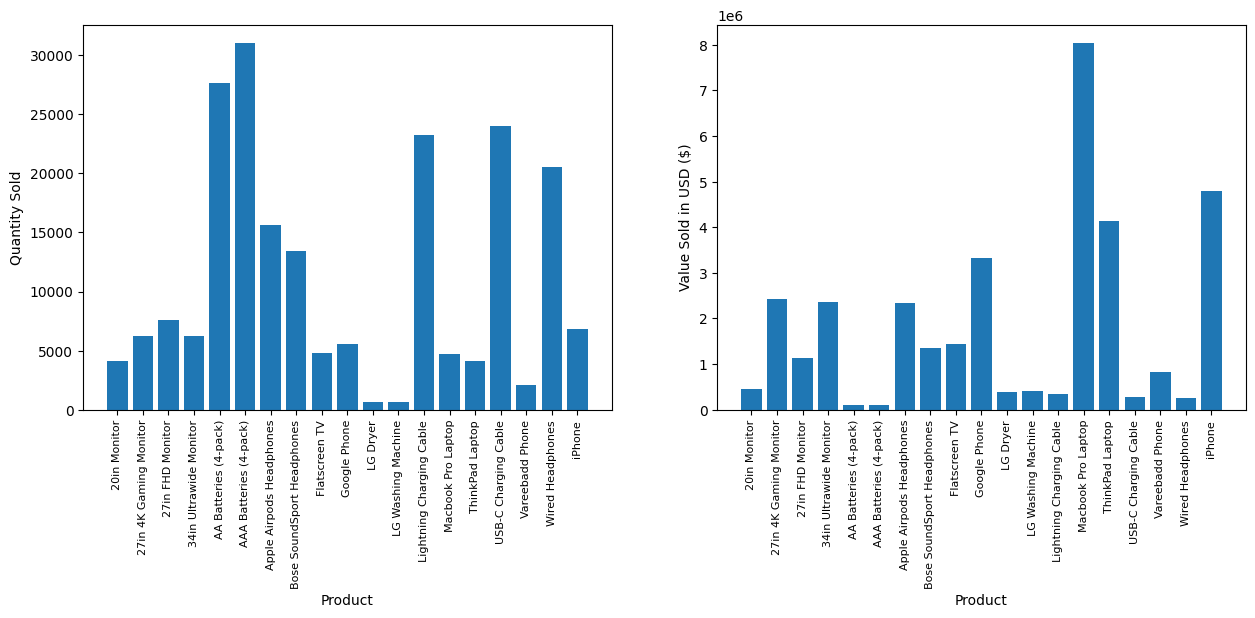

In [54]:
plt.figure(figsize=(15,5))

# most sold by quantity
plt.subplot(121)
plt.bar(sales_by_product['Product'], sales_by_product['Quantity Ordered'])
plt.xticks(sales_by_product['Product'], rotation='vertical', size=8)
plt.ylabel('Quantity Sold')
plt.xlabel('Product')

# most sold by total money
plt.subplot(122)
plt.bar(sales_by_product['Product'], sales_by_product['Sales'])
plt.xticks(sales_by_product['Product'], rotation='vertical', size=8)
plt.ylabel('Value Sold in USD ($)')
plt.xlabel('Product')

plt.show()

<ipython-input-59-87a022ea9cf6>:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(sales_by_product['Product'], rotation='vertical', size=8)


<Figure size 1000x600 with 0 Axes>

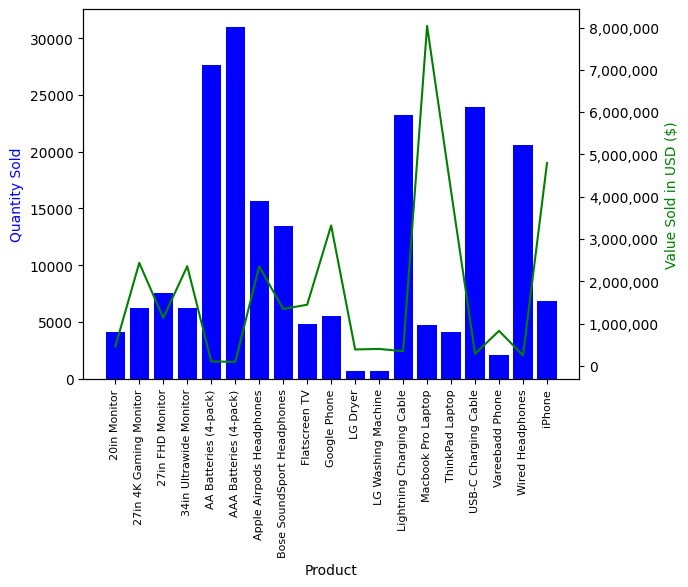

In [59]:
# show both in same figure
plt.figure(figsize=(10,6))
fig, ax1 = plt.subplots()


ax2 = ax1.twinx()
ax1.bar(sales_by_product['Product'], sales_by_product['Quantity Ordered'], color='b')
ax2.plot(sales_by_product['Product'], sales_by_product['Sales'], color='g')

ax1.set_xlabel('Product')
ax1.set_ylabel('Quantity Sold', color='b')
ax2.set_ylabel('Value Sold in USD ($)', color='g')
ax1.set_xticklabels(sales_by_product['Product'], rotation='vertical', size=8)

ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))


fig.show()